# Install

In [2]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cach

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


# Import Library

In [32]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import os
from sklearn.model_selection import train_test_split

# Preprocessing

In [33]:
TRAINING_DIR = 'archive/ck/Train'
VALIDATION_DIR = 'archive/Test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.1
)

train_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32
)

Found 981 images belonging to 7 classes.


In [37]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32
)

Found 981 images belonging to 7 classes.


In [36]:
for split, directory in [("Train", TRAINING_DIR), ("Validation", VALIDATION_DIR)]:
  print(f"\n {split}:")
  for kelas in sorted(os.listdir(directory)):
    kelas_path = os.path.join(directory, kelas)
    if os.path.isdir(kelas_path):
      jumlah = len(os.listdir(kelas_path))
      print(f"{kelas}: {jumlah} gambar")


 Train:
anger: 135 gambar
contempt: 54 gambar
disgust: 177 gambar
fear: 75 gambar
happy: 207 gambar
sadness: 84 gambar
surprise: 249 gambar

 Validation:
anger: 135 gambar
contempt: 54 gambar
disgust: 177 gambar
fear: 75 gambar
happy: 207 gambar
sadness: 84 gambar
surprise: 249 gambar


# Create a Model

In [42]:
pre_trained_model = MobileNetV2(weights="imagenet", include_top=False,
                                input_tensor=Input(shape=(224, 224, 3)))

# freeze
for layer in pre_trained_model.layers:
    layer.trainable = False

last_output = pre_trained_model.output

C:\Users\USER\AppData\Local\Temp\ipykernel_51756\693608538.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  pre_trained_model = MobileNetV2(weights="imagenet", include_top=False,


In [43]:
x = tf.keras.layers.Flatten()(last_output)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dense(7, activation='softmax')(x)

model = tf.keras.Model(pre_trained_model.input, x)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 10,287,175 (39.24 MB)

 Trainable params: 8,029,191 (30.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Training Model

In [44]:
int_lr = 0.0001
epochs = 30
optimizer = tf.keras.optimizers.Adam(learning_rate=int_lr)
model.compile(optimizer=optimizer, loss='categorical_crossentropy',
              metrics=['accuracy'])

In [45]:
H = model.fit(train_generator,
              epochs=epochs,
              validation_data=validation_generator)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.3761 - loss: 1.9398 - val_accuracy: 0.5596 - val_loss: 1.2015
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.5576 - loss: 1.2678 - val_accuracy: 0.6198 - val_loss: 1.0180
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.6045 - loss: 1.0730 - val_accuracy: 0.6575 - val_loss: 0.8837
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6534 - loss: 0.9887 - val_accuracy: 0.7166 - val_loss: 0.8273
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6830 - loss: 0.9220 - val_accuracy: 0.7594 - val_loss: 0.6801
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7044 - loss: 0.8443 - val_accuracy: 0.7931 - val_loss: 0.6209
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7156 - loss: 0.8223 - val_accuracy: 0.7676 - val_loss: 0.6746
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.7390 - loss: 0.7391 - val_accuracy: 0.8206 - val_loss:

In [57]:
model.save('best_model.keras')
print("Tersimpan!")

Tersimpan!


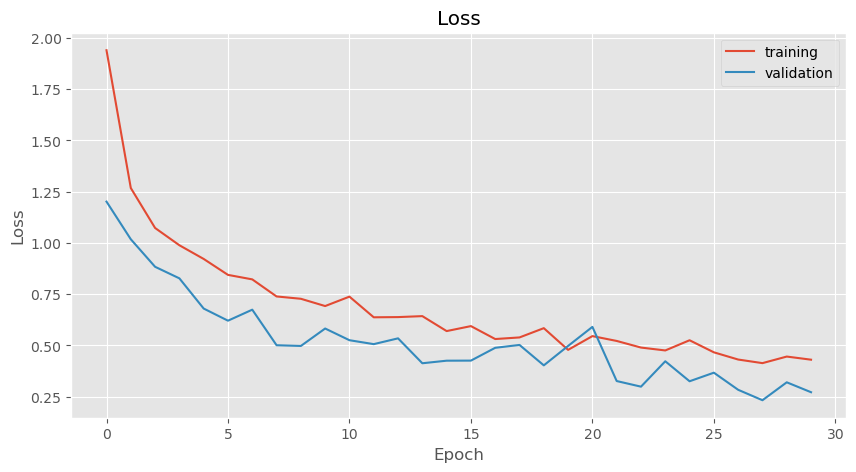

In [46]:
plt.style.use("ggplot")
plt.figure(figsize=(10, 5))
plt.plot(np.arange(0, epochs), H.history["loss"], label="training")
plt.plot(np.arange(0, epochs), H.history["val_loss"], label="validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

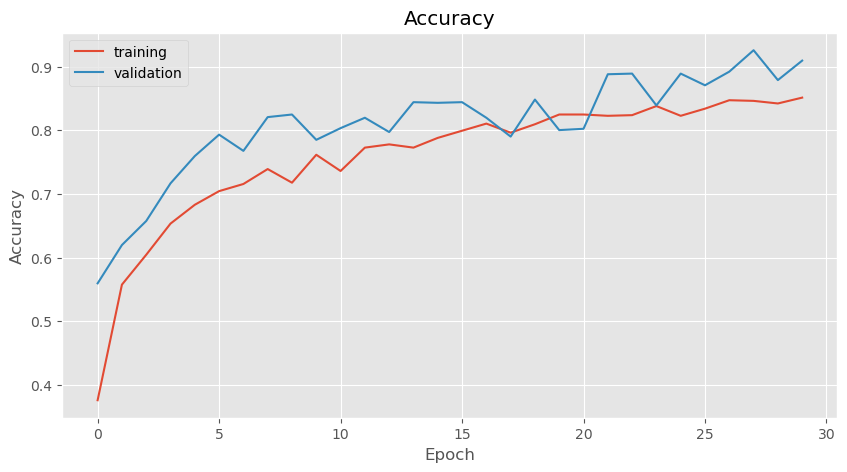

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(0, epochs), H.history["accuracy"], label="training")
plt.plot(np.arange(0, epochs), H.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Fine-Tuning

In [60]:
pre_trained_model.trainable = True

fine_tune_at = 100
for layer in pre_trained_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    
H = model.fit(train_generator,
              epochs=30,
              validation_data=validation_generator)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8899 - loss: 0.2953 - val_accuracy: 0.8950 - val_loss: 0.3721
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8756 - loss: 0.3267 - val_accuracy: 0.8858 - val_loss: 0.4105
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9042 - loss: 0.2777 - val_accuracy: 0.8828 - val_loss: 0.4019
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8919 - loss: 0.2882 - val_accuracy: 0.8675 - val_loss: 0.4352
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8858 - loss: 0.3003 - val_accuracy: 0.8970 - val_loss: 0.3359
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8960 - loss: 0.3032 - val_accuracy: 0.9042 - val_loss: 0.2993
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.9235 - loss: 0.2397 - val_accuracy: 0.8950 - val_loss: 0.3484
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9144 - loss: 0.2580 - val_accuracy: 0.9042 - val_loss:

# Save Model

In [72]:
model.save('after_fineTuning.keras')
print("Model tersimpan!")

Model tersimpan!


In [ ]:
model = tf.keras.models.load_model('after_fineTuning.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()  

import pathlib
pathlib.Path('model.tflite').write_bytes(tflite_model)
print(f"Berhasil! Ukuran: {len(tflite_model)/1024:.1f} KB")

INFO:tensorflow:Assets written to: C:\Users\USER\AppData\Local\Temp\tmpksdeybju\assets


INFO:tensorflow:Assets written to: C:\Users\USER\AppData\Local\Temp\tmpksdeybju\assets


Saved artifact at 'C:\Users\USER\AppData\Local\Temp\tmpksdeybju'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_6')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2686381339088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381341200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381342160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381341776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381341392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381342352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381341584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381340816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381341968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2686381342544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  26863

# Inference

Prediksi  : surprise
Confidence: 100.00%
Label asli: surprise


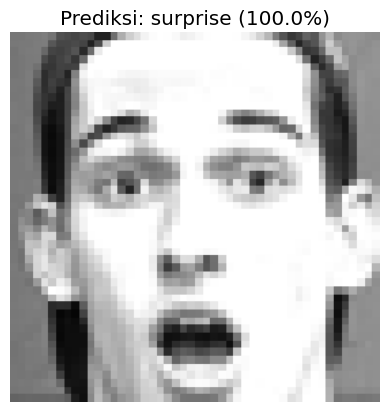

In [88]:
import numpy as np

interpreter = tf.lite.Interpreter(model_path='model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_images, sample_labels = next(validation_generator)
sample_input = np.expand_dims(sample_images[0], axis=0).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], sample_input)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(output)
class_names = list(validation_generator.class_indices.keys())

print(f"Prediksi  : {class_names[predicted_class]}")
print(f"Confidence: {output[0][predicted_class]*100:.2f}%")
print(f"Label asli: {class_names[np.argmax(sample_labels[0])]}")

import matplotlib.pyplot as plt
plt.imshow(sample_images[0])
plt.title(f"Prediksi: {class_names[predicted_class]} ({output[0][predicted_class]*100:.1f}%)")
plt.axis('off')
plt.show()

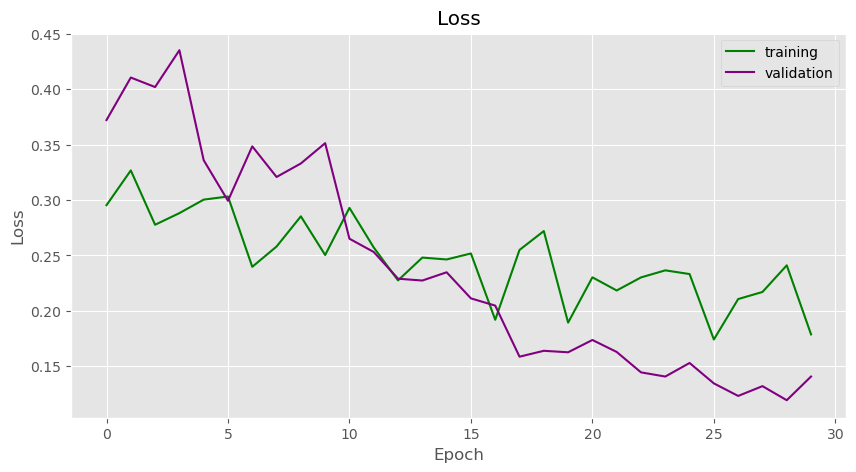

In [66]:
plt.style.use("ggplot")
plt.figure(figsize=(10, 5))
plt.plot(np.arange(0, epochs), H.history["loss"], label="training", color='green')
plt.plot(np.arange(0, epochs), H.history["val_loss"], label="validation", color='purple')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

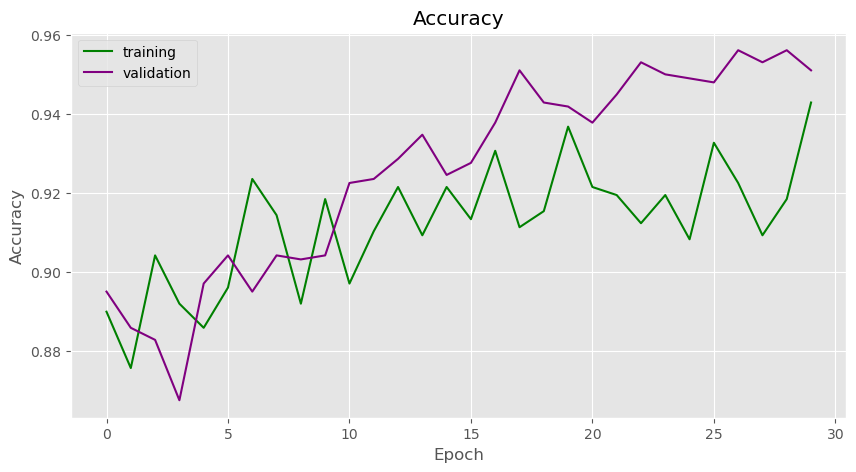

In [67]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(0, epochs), H.history["accuracy"], label="training", color='green')
plt.plot(np.arange(0, epochs), H.history["val_accuracy"], label="validation", color='purple')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


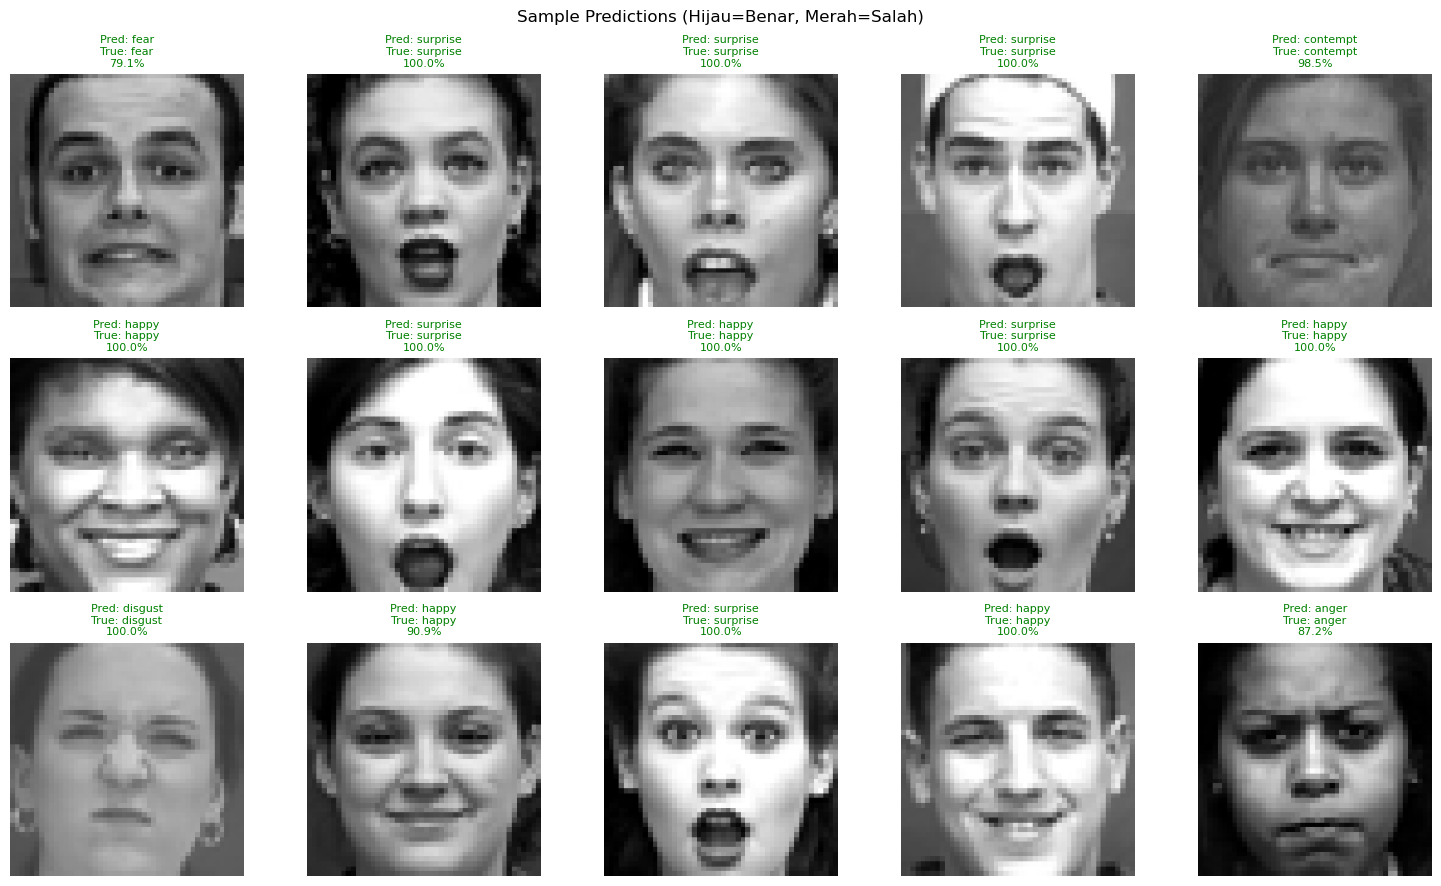

In [63]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

sample_images, sample_labels = next(validation_generator)
predictions = model.predict(sample_images)
class_names = list(validation_generator.class_indices.keys())

for i in range(15):
    axes[i].imshow(sample_images[i])
    pred = class_names[np.argmax(predictions[i])]
    true = class_names[np.argmax(sample_labels[i])]
    confidence = np.max(predictions[i]) * 100
    
    color = 'green' if pred == true else 'red'
    axes[i].set_title(f'Pred: {pred}\nTrue: {true}\n{confidence:.1f}%', 
                      color=color, fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Hijau=Benar, Merah=Salah)', fontsize=12)
plt.tight_layout()
plt.show()

# Predict by Image

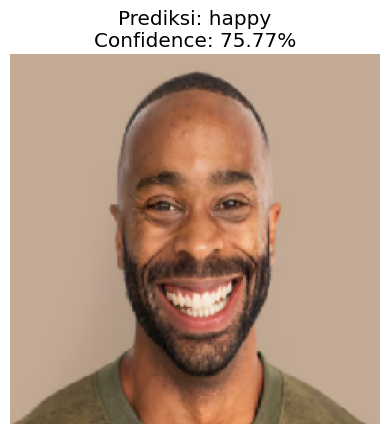

Prediksi  : happy
Confidence: 75.77%


In [96]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_image(img_path):
    # Load and resize image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)
    
    # Prediction
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    
    predicted_class = np.argmax(output)
    confidence = output[0][predicted_class]*100
    class_names = list(validation_generator.class_indices.keys())
    
    # Result
    plt.imshow(img)
    plt.title(f"Prediksi: {class_names[predicted_class]}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()
    
    print(f"Prediksi  : {class_names[predicted_class]}")
    print(f"Confidence: {confidence:.2f}%")

# Calling function with your image path
predict_image('Screenshot 2026-05-03 001217.png')

In [97]:
import json

filepath = r'd:\machine learning\Klasifikasi Gambar Penoumia\Latihan_Klasifikasi_Gambar.ipynb'

with open(filepath, 'r', encoding='utf-8') as f:
    nb = json.load(f)

print(nb.get('metadata', {}).keys())

dict_keys(['accelerator', 'colab', 'kernelspec', 'language_info', 'widgets'])


In [98]:
with open(filepath, 'r', encoding='utf-8') as f:
    nb = json.load(f)

print(nb.get('metadata', {}).keys())  

dict_keys(['accelerator', 'colab', 'kernelspec', 'language_info', 'widgets'])
